#INFORMACIÓN GENERAL

UNIVERSIDAD NACIONAL DE SAN ANTONIO ABAD DEL CUSCO

ESCUELA PROFESIONAL DE INGENIERÍA INFORMÁTICA Y DE SISTEMAS

INTELIGENCIA ARTIFICIAL

LABORATORIO 07: SISTEMAS EXPERTOS - INTRODUCCIÓN


##Marco teórico

###Sistema experto

Es un sistema informático que emula el razonamiento actuando tal y como lo haría un experto en cualquier área del conocimiento

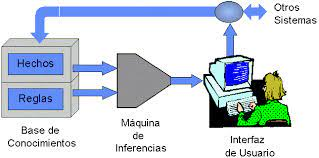

###Base de conocimientos

Una Base de conocimiento es un conjunto de datos intrínsecos relevantes al dominio de un problema, y un conjunto de reglas que determinan los procedimientos aplicables a los datos.<br>

**Elementos de una base de datos**<br>

**Hechos**.- Son cláusulas que expresan parte del conocimiento. Los hechos son características de los objetos o representaciones de relaciones entre objetos. Ejemplos:<br>
*La UNSAAC es una universidad*<br>
*Juan es el padre de Luis*<br>

**Reglas**.- Son cláusulas que describen una acción dinámica relativa al dominio de los elementos. Su estructura está dada por un conjunto de condiciones denominados antecedentes y una acción a tomar, llamada consecuente. Ejemplo:<br>
*Si X es padre de Y y Y es padre de Z, entonces, X es ancestro de Z.*<br>

**Objetivos**.- Son cláusulas que expresan lo que se desea demostrar. Un objetivo se resuelve con las reglas y/o los  hechos.

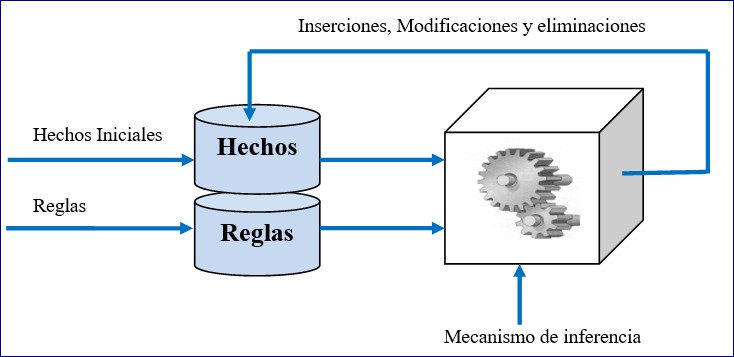


###Máquinas o motores de inferencia

Son algoritmos responsables de determinar las estrategias de búsqueda en la base de conocimientos para producir el conocimiento demandado.<br>

Es responsabilidad del motor de inferencia:<br>
- Examinar los hechos y reglas. En caso de deducir nueva información, añadir a la base de hechos.<br>
- Decidir el orden en que se hace las inferencias.<br>


## Parte práctica

###Descripción de la librería

https://pypi.org/project/pyDatalog/

###Instalación de la librería

In [ ]:
!pip install pyDatalog

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 7.5 MB/s eta 0:00:00


###Importación de la librería

In [ ]:
from pyDatalog import pyDatalog

###Ejercicio 01

####Enunciado

Se desea gestionar la información de qué animales son más grandes. Por ejemplo:<br>
*El elefante es más grande que el búfalo.*<br>
*El búfalo es más grande que el léon.*<br>

####Base de conocimientos

In [ ]:
#Limpiar la base de conocimientos
pyDatalog.clear()

#####Hechos


In [ ]:
#Definir identificadores
pyDatalog.create_terms('masgrande')
# -- Hechos
+masgrande('elefante','búfalo')
+masgrande('búfalo','león')
+masgrande('león','chacal')

In [ ]:
pyDatalog.create_terms('X, Y')
masgrande(X,Y)


[('león', 'chacal'), ('búfalo', 'león'), ('elefante', 'búfalo')]

#####Reglas

In [ ]:
#Definir identificadores
pyDatalog.create_terms('muchomasgrande')
#Definir variables
pyDatalog.create_terms('X, Y, Z')
# -- Reglas
muchomasgrande(X,Z) <= masgrande(X,Y) & masgrande(Y,Z)


muchomasgrande(X,Z) <= masgrande(X,Y)&masgrande(Y,

In [ ]:
muchomasgrande(X,Z)


[('búfalo', 'chacal'), ('elefante', 'león')]

####Procesos de inferencia

a) Determinar qué animales son más **grandes**

In [ ]:
# -- Determinar qué animal es el más grande
rpta = masgrande(X,Y)
print(rpta)

X        | Y     
---------|-------
león     | chacal
búfalo   | león  
elefante | búfalo


b) Determinar que animal es mucho más grande

In [ ]:
# -- Determinar qué animal es mucho más grande
rpta = muchomasgrande(X,Y)
print(rpta)

X        | Y     
---------|-------
búfalo   | chacal
elefante | león  


c) Determina que animal es mucho más grande que el león

In [ ]:
# -- Determinar qué animal es más grande que el león
rpta = muchomasgrande(X,'chacal')
print(rpta)

X     
------
búfalo


d) Agregar más hechos a la base de conocimiento, por ejemplo:<br>
+masgrande('león','leopardo')<br>
+masgrande('leopardo','hiena')<br>
+masgrande('hiena','chacal')<br>
+masgrande('chacal','suricata')<br>

Luego verificar qué animales son mucho más grandes. Considerar que un elefante es mucho más grande que un leopardo o una hiena.

En caso de no concordar con el análisis lógico, considerar la posibilidad de agregar más reglas, de modo que se tenga todas las posibilidades de animales mucho más grandes.

SOLUCIÓN

In [ ]:
#Limpiar la base de conocimientos
pyDatalog.clear()


In [ ]:
# -- Hechos
+masgrande('elefante','búfalo')
+masgrande('búfalo','león')
+masgrande('león','leopardo')
+masgrande('leopardo','hiena')
+masgrande('hiena','chacal')
+masgrande('chacal','suricata')
# -- Reglas
muchomasgrande(X,Z) <= masgrande(X,Y) & masgrande(Y,Z)
muchomasgrande(X,Z) <= masgrande(X,Y) & muchomasgrande(Y,Z)


muchomasgrande(X,Z) <= masgrande(X,Y)&muchomasgran

In [ ]:
# -- Proceso de inferencia
rpta = muchomasgrande(X,Z)
print(rpta.sort())

X        | Z       
---------|---------
búfalo   | chacal  
búfalo   | hiena   
búfalo   | leopardo
búfalo   | suricata
elefante | chacal  
elefante | hiena   
elefante | leopardo
elefante | león    
elefante | suricata
hiena    | suricata
leopardo | chacal  
leopardo | suricata
león     | chacal  
león     | hiena   
león     | suricata


###Ejercicio 02

####Enunciado

Implementar una base de conocimientos, de modo que se pueda representar lo siguiente:
- Los loros, los gallos y las halcones son aves.
- Lucas es un loro.
- Perico es hijo de Lucas.
- Carmelo es un gallo.
- El hijo de un halcón es un halcón.
- El hijo de un loro es un loro.
- Aquiles es un halcón.
- Aquiles es padre de Ares.
- Padre e hijo son relaciones inversas
- Mostrar la relación de halcones
- Cada ave tiene un padre

####Base de conocimientos

In [ ]:
#Limpiar la base de conocimientos
pyDatalog.clear()

#####Hechos

$Loro(Lucas)$<br>
$Gallo(Carmelo)$<br>
$Halcon(Aquiles)$<br>
$Hijo(Perico,Lucas)$<br>
$Padre(Aquiles,Ares)$<br>

In [ ]:
#Definir identificadores
pyDatalog.create_terms('loro, gallo, halcon, hijo, padre')
# -- Hechos
+loro('lucas')
+gallo('carmelo')
+halcon('aquiles')
+hijo('perico','lucas')
+padre('aquiles','ares')

#####Reglas

$Loro(x) ⇒ Ave(x)$<br>
$Gallo(x) ⇒ Ave(x)$<br>
$Halcon(x) ⇒ Ave(x)$<br>
$Halcon(y) ∧ Hijo(x,y) ⇒ Halcon(x)$<br>
$Hijo(x,y) ⇒ Padre(y,x)$<br>
$Padre(x,y) ⇒ Hijo(y,x)$<br>
$Ave(x) ⇒ Padre(y,x)$<br>

In [ ]:
#Definir identificadores
pyDatalog.create_terms('ave')
#Definir variables
pyDatalog.create_terms('X, Y')

ave(X) <= loro(X)
ave(X) <= gallo(X)
ave(X) <= halcon(X)
loro(X) <= loro(Y) & hijo(X,Y)
halcon(Y) <= halcon(X) & padre(X,Y)
hijo(X,Y) <= padre(Y,X)
padre(X,Y) <= hijo(Y,X)
ave(X) <= padre(Y,X)

ave(X) <= padre(Y,X)

####Procesos de inferencia

a) Determinar la relaciónde aves.

In [ ]:
rpta = ave(X)
print(rpta)

X      
-------
perico 
ares   
aquiles
carmelo
lucas  


b) Determinar la relación de loros.

In [ ]:
rpta = loro(X)
print(rpta)

X     
------
lucas 
perico


c) Determinar la relación de gallos.

In [ ]:
rpta = gallo(X)
print(rpta)

X      
-------
carmelo


d) Determinar la relación de halcones.

In [ ]:
rpta = halcon(X)
print(rpta)

X      
-------
aquiles
ares   


e) Determinar la relación de padres

In [ ]:
print(padre(X,Y))

X       | Y     
--------|-------
lucas   | perico
aquiles | ares  


###Ejercicio 03

####Enunciado

“La ley dice que es un crimen para un americano vender armas a países hostiles. El país Nono, un enemigo de América, tiene algunos misiles, y todos sus misiles fueron vendidos por el Coronel West, que es americano.”

####Base de conocimientos

In [ ]:
#Limpiar la base de conocimientos
pyDatalog.clear()

#####Hechos

$Tiene(Nono, M1)$<br>
$Misil(M1)$<br>
$Americano(West)$<br>
$Enemigo(Nono,América)$<br>

In [ ]:
#Definir identificadores
pyDatalog.create_terms('tiene, misil, americano, enemigo')
#Hechos
+tiene('nono','m1')
+misil('m1')
+americano('west')
+enemigo('nono','america')


#####Reglas

$Americano(x) ∧ Arma(y) ∧ Vende(x,y,z) ∧ Hostil(z) ⇒ Criminal(x)$<br>
$Misil(x) ∧ Tiene(Nono,x) ⇒ Vende(West,x,Nono)$<br>
$Misil(x) ⇒ Arma(x)$<br>
$Enemigo(x, América) ⇒ Hostil(x)$<br>

In [ ]:
# -- Definir identificadores
pyDatalog.create_terms('criminal, vende, arma, hostil')
# -- Definir variables
pyDatalog.create_terms('X, Y, Z')
# -- Reglas
criminal(X) <= americano(X), arma(Y), vende(X,Y,Z), hostil(Z)
vende('west',X,'nono') <= misil(X), tiene('nono',X)
arma(X) <= misil(X)
hostil(X) <= enemigo(X,'america')

hostil(X) <= enemigo(X,'america')

####Procesos de inferencia

a) ¿Qué tiene el país nono?

In [ ]:
print(tiene('nono',X))

X 
--
m1


b) ¿Quién es americano?

In [ ]:
print(americano(X))

X   
----
west


c) ¿Que país es hostil?

In [ ]:
print(hostil(X))

X   
----
nono


d) ¿Qué vende west a nono?

In [ ]:
print(vende('west',X,'nono'))

X 
--
m1


e) ¿Quién es criminal?

In [ ]:
rpta = criminal(X)
print(rpta)

X   
----
west


###Ejercicio 04

####Enunciado

Matías es un niño de 5 años que acaba de aprender los números y, después de escuchar a su primo llamar "anciana" a su hermana, quiere saber a qué edad una persona es bebé, niño, adolescente,  adulto y anciano. Su madre le explicó que una persona es:<br>
• Bebé desde que nace hasta que tiene 2 años inclusive.<br>
• Niño desde los 3 hasta los 9 años inclusive.<br>
• Adolescente desde los 10 hasta los 20 años inclusive.<br>
• Adulto desde los 21 hasta los 69 años inclusive.<br>
• Anciano desde los 70 años en adelante.<br>
En base a esto, la mamá le pide que le
responda en qué categoría se encuentra cada uno de sus familiares, teniendo en cuenta el siguiente árbol:

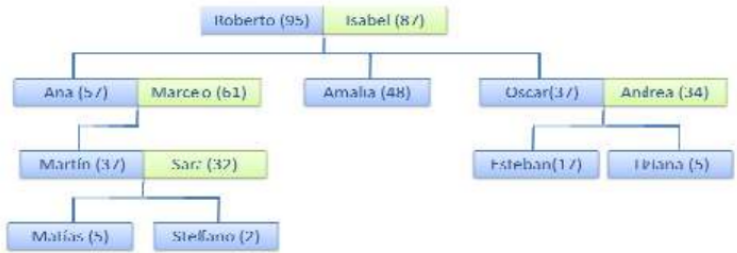

####Base de conocimientos

In [ ]:
#Limpiar la base de conocimientos
pyDatalog.clear()

#####Hechos

In [ ]:
#Definir identificadores
pyDatalog.create_terms('edad')
#Hechos
+edad('roberto',95)
+edad('isabel',87)
+edad('ana',57)
+edad('marcelo',61)
+edad('amalia',48)
+edad('oscar',37)
+edad('andrea',34)
+edad('martin',37)
+edad('sara',32)
+edad('esteban',17)
+edad('tiziana',5)
+edad('matias',5)
+edad('estefano',2)


#####Reglas

In [ ]:
#Definir identificadores
pyDatalog.create_terms('bebe, niño, adolescente, adulto, anciano, X, A, T, M, J, L')
#Reglas
bebe(X)<= (edad(X,A) & (A<=2))
niño(X)<= (edad(X,T) & (T>=3) & (T<=9))
adolescente(X)<= (edad(X,M) & (M>=10) & (M<=20))
adulto(X)<= (edad(X,J) & (J>=21) & (J<=69))
anciano(X)<= (edad(X,L) & (L>=70) & (L<=150))

anciano(X) <= edad(X,L)&>=(L,'70')&<=(L,'150')

####Procesos de inferencia

In [ ]:
adulto(X)

[('sara',), ('martin',), ('andrea',), ('oscar',), ('amalia',), ('marcelo',), ('ana',)]

In [ ]:
print(niño(X))

X      
-------
matias 
tiziana


####Incrementando la base de conocimientos

#####Más reglas

En base a las edades de los parientes de Matías, crear reglas que determine si una persona es: <br>
• mayor que otra<br>
• menor que otra <br>
• de la misma edad que otra <br>

In [ ]:
#Definir identificadores
pyDatalog.create_terms('mayor_que, menor_que, igual_que, X, Y, Z, V')
#Reglas
mayor_que(X,Y)<= (edad(X,Z) & edad(Y,V) & (Z>V))
menor_que(X,Y)<= (edad(X,Z) & edad(Y,V) & (Z<V))
igual_que(X,Y)<= (edad(X,Z) & edad(Y,Z) & (X!=Y))

igual_que(X,Y) <= edad(X,Z)&edad(Y,Z)&!=(X,Y)

In [ ]:
igual_que(X,Y)


[('matias', 'tiziana'), ('tiziana', 'matias'), ('martin', 'oscar'), ('oscar', 'martin')]

Definir los parentescos existentes en la familia de Matías, según el árbol genealógico del punto anterior. Se debe cargar como hecho las relaciones de padre y de esposo, luego crear las reglas para: hermano, hijo, tio, sobrino, primo, abuelo, nieto, bisabuelo, bisnieto, cuñado. Luego, ejecutar los siguientes objetivos:

#####Más hechos

In [ ]:
#Definir identificadores

#Hechos


#####Más reglas

In [ ]:
#Definir identificadores
pyDatalog.create_terms('hermano, hijo, abuelo, tio, sobrino, primo')
#Reglas


In [ ]:
print(abuelo(X,Y))

##Ejercicios propuestos

###Ejercicio 01

**1.- Codificar los siguientes hechos y reglas en  pyDatalog:**

·         Oso es grande

·         Elefante es grande

·         Gato es pequeño

·         Oso es marron

·         Gato es negro

·         Elefante es plomo

·         Un animal es oscuro si es negro

·         Un animal es oscuro si es marron

Escribe una consulta para saber que animal es oscuro y grande  



###Ejercicio 02

**2.- Implementar usando pyDatalog su árbol genealógico**
